<a href="https://colab.research.google.com/github/Aline-CROIRE/FarmSync/blob/main/FarmerSync_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os


file_path = 'farmersync_main_dataset.csv'

if not os.path.exists(file_path):
    print(" ERROR: Please upload 'farmersync_main_dataset.csv' to the Colab sidebar first!")
else:
    df = pd.read_csv(file_path)
    print(" Data Loaded Successfully!")


    print("\n--- Running Verification Tests ---")


    null_counts = df.isnull().sum().sum()
    print(f"1. Missing Values: {null_counts} (Expected: 0)")


    min_p, max_p = df['price'].min(), df['price'].max()
    print(f"2. Price Range: {min_p} to {max_p} (Expected: 200 to 1200)")


    print(f"3. Total Records: {len(df)} (Expected: 100,000)")


    print("\n4. Column Data Types:")
    print(df.dtypes)

    # Summary Statistics for a sanity check
    print("\n--- Summary Statistics ---")
    display(df.describe())

In [7]:
import pandas as pd
import numpy as np


df = pd.read_csv('farmersync_main_dataset.csv')


df['date'] = pd.to_datetime(df['date'])


zone_map = {'Eastern': 0, 'Southern': 1, 'Western': 2, 'Northern': 3, 'Kigali': 4}
df['zone_id'] = df['climate_zone'].map(zone_map)


df = df.sort_values(by=['zone_id', 'date'])
df['prev_day_price'] = df.groupby('zone_id')['price'].shift(1)

df = df.dropna()

print("--- PREPROCESSING VERIFICATION ---")

unique_zones = df['zone_id'].unique()
print(f"1. Encoded Zones found: {unique_zones} (Expected: [0 1 2 3 4])")


correlation = df['price'].corr(df['harvest_quantity'])
print(f"2. Correlation (Price vs Harvest): {correlation:.4f}")

if correlation < -0.4:
    print(" LOGIC PASS: Strong inverse relationship found. This data is realistic.")
else:
    print("LOGIC WARNING: Relationship is weak. The model might struggle.")


print(f"3. Final data rows: {len(df)} (Expected: 99,995)")


display(df[['date', 'climate_zone', 'zone_id', 'harvest_quantity', 'prev_day_price', 'price']].head())


--- PREPROCESSING VERIFICATION ---
1. Encoded Zones found: [0 1 2 3 4] (Expected: [0 1 2 3 4])
2. Correlation (Price vs Harvest): -0.6034
✅ LOGIC PASS: Strong inverse relationship found. This data is realistic.
3. Final data rows: 99995 (Expected: 99,995)


,date,climate_zone,zone_id,harvest_quantity,prev_day_price,price
5,1950-01-02,Eastern,0,9887.948307,200.0,200
6,1950-01-02,Eastern,0,9140.816479,200.0,200
10,1950-01-03,Eastern,0,9644.546899,200.0,200
13,1950-01-04,Eastern,0,9702.619210,200.0,200
14,1950-01-04,Eastern,0,6112.521834,200.0,200


In [9]:
from sklearn.model_selection import train_test_split


features = [
    'zone_id', 'temperature', 'rainfall_mm', 'humidity',
    'harvest_quantity', 'transport_cost', 'market_demand_index',
    'prev_day_price'
]
target = 'price'

X = df[features]
y = df[target]
g.
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print("--- DATA SPLIT VERIFICATION ---")
print(f"1. Training features shape: {X_train.shape} (Expected ~80,000 rows)")
print(f"2. Testing features shape: {X_test.shape} (Expected ~20,000 rows)")


if 'price' in X_train.columns:
    print(" ERROR: 'price' is inside your features! The model will cheat.")
else:
    print(" TEST PASSED: No target leakage.")


print(f"3. Training starts from row 0, Testing starts from row {split_index}")

--- DATA SPLIT VERIFICATION ---
1. Training features shape: (79996, 8) (Expected ~80,000 rows)
2. Testing features shape: (19999, 8) (Expected ~20,000 rows)
 TEST PASSED: No target leakage.
3. Training starts from row 0, Testing starts from row 79996


In [10]:

with open(f"{repo_name}/split_report.txt", "w") as f:
    f.write("STEP 3: DATA SPLIT SUMMARY\n")
    f.write(f"Features used: {features}\n")
    f.write(f"Training set size: {len(X_train)}\n")
    f.write(f"Testing set size: {len(X_test)}\n")
    f.write("Method: Chronological Split (80/20)\n")



/content/farm-sync-ml
[main cb77235] Step 3: Data split into Train/Test sets
 1 file changed, 5 insertions(+)
 create mode 100644 split_report.txt
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 574 bytes | 574.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Aline-CROIRE/farm-sync-ml.git
   5286789..cb77235  main -> main
/content
 Step 3 pushed to GitHub!


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)


print("⏳ Training Linear Regression...")
lr_model.fit(X_train, y_train)

print("⏳ Training Decision Tree...")
dt_model.fit(X_train, y_train)


lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)


lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

dt_r2 = r2_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)

print("\n--- MODEL PERFORMANCE RESULTS ---")
print(f"MODEL 1: Linear Regression")
print(f"   - Accuracy (R2 Score): {lr_r2:.4f}")
print(f"   - Error (MAE): {lr_mae:.2f} RWF")

print(f"\nMODEL 2: Decision Tree")
print(f"   - Accuracy (R2 Score): {dt_r2:.4f}")
print(f"   - Error (MAE): {dt_mae:.2f} RWF")

⏳ Training Linear Regression...
⏳ Training Decision Tree...

--- MODEL PERFORMANCE RESULTS ---
MODEL 1: Linear Regression
   - Accuracy (R2 Score): 0.4735
   - Error (MAE): 155.23 RWF

MODEL 2: Decision Tree
   - Accuracy (R2 Score): 0.3935
   - Error (MAE): 131.44 RWF


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


improved_features = [
    'year', 'zone_id', 'temperature', 'rainfall_mm', 'humidity',
    'harvest_quantity', 'transport_cost', 'market_demand_index',
    'prev_day_price'
]

X_improved = df[improved_features]
y = df['price']


split_idx = int(len(df) * 0.8)
X_train_imp = X_improved.iloc[:split_idx]
X_test_imp = X_improved.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


lr_imp = LinearRegression()
dt_imp = DecisionTreeRegressor(random_state=42)

lr_imp.fit(X_train_imp, y_train)
dt_imp.fit(X_train_imp, y_train)


lr_preds = lr_imp.predict(X_test_imp)
dt_preds = dt_imp.predict(X_test_imp)

print("--- IMPROVED MODEL RESULTS (Year included) ---")
print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.4f}")
print(f"Decision Tree R2: {r2_score(y_test, dt_preds):.4f}")
print(f"Decision Tree Error (MAE): {mean_absolute_error(y_test, dt_preds):.2f} RWF")

--- IMPROVED MODEL RESULTS (Year included) ---
Linear Regression R2: 0.7695
Decision Tree R2: 0.8804
Decision Tree Error (MAE): 46.87 RWF


In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb #
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

print(" Training Random Forest (Model 3/5)...")
rf_model.fit(X_train_imp, y_train)

print(" Training Gradient Boosting (Model 4/5)...")
gb_model.fit(X_train_imp, y_train)

print("Training XGBoost (Model 5/5)...")
xgb_model.fit(X_train_imp, y_train)


def get_scores(model, name):
    preds = model.predict(X_test_imp)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name} -> R2 Score: {r2:.4f} | Error: {mae:.2f} RWF")
    return r2, mae

print("\n--- FINAL MODEL COMPARISON ---")
rf_r2, rf_mae = get_scores(rf_model, "Random Forest")
gb_r2, gb_mae = get_scores(gb_model, "Gradient Boosting")
xgb_r2, xgb_mae = get_scores(xgb_model, "XGBoost")

⏳ Training Random Forest (Model 3/5)...
⏳ Training Gradient Boosting (Model 4/5)...
⏳ Training XGBoost (Model 5/5)...

--- FINAL MODEL COMPARISON ---
Random Forest -> R2 Score: 0.9384 | Error: 37.39 RWF
Gradient Boosting -> R2 Score: 0.9305 | Error: 42.60 RWF
XGBoost -> R2 Score: 0.9497 | Error: 37.08 RWF


In [15]:

with open(f"{repo_name}/model_comparison.txt", "w") as f:
    f.write("FINAL MODEL EVALUATION\n")
    f.write(f"Linear Regression: R2={r2_score(y_test, lr_preds):.4f}\n")
    f.write(f"Decision Tree: R2={dt_r2:.4f}\n")
    f.write(f"Random Forest: R2={rf_r2:.4f}\n")
    f.write(f"Gradient Boosting: R2={gb_r2:.4f}\n")
    f.write(f"XGBoost: R2={xgb_r2:.4f}\n")



/content/farm-sync-ml
[main 5a5f0c4] Step 5: Trained all 5 models and compared results
 1 file changed, 6 insertions(+)
 create mode 100644 model_comparison.txt
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 438 bytes | 438.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Aline-CROIRE/farm-sync-ml.git
   cb77235..5a5f0c4  main -> main
/content
 Step 5 results pushed to GitHub!


In [16]:

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


df['harvest_7day_avg'] = df.groupby('zone_id')['harvest_quantity'].transform(lambda x: x.rolling(window=7).mean())


df_advanced = df.dropna()

super_features = [
    'year', 'month', 'is_weekend', 'zone_id',
    'temperature', 'rainfall_mm', 'humidity',
    'harvest_quantity', 'harvest_7day_avg',
    'transport_cost', 'market_demand_index',
    'prev_day_price'
]

X_adv = df_advanced[super_features]
y_adv = df_advanced['price']

#  Re-split
split_idx = int(len(df_advanced) * 0.8)
X_train_adv = X_adv.iloc[:split_idx]
X_test_adv = X_adv.iloc[split_idx:]
y_train_adv = y_adv.iloc[:split_idx]
y_test_adv = y_adv.iloc[split_idx:]

print(f" New feature count: {len(super_features)} (Was 9, now 12)")
print(f"Ready to re-train with Seasonality and Rolling averages.")

 New feature count: 12 (Was 9, now 12)
Ready to re-train with Seasonality and Rolling averages.


In [17]:

print(" Training Optimized Random Forest (Deeper trees)...")
rf_opt = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
rf_opt.fit(X_train_adv, y_train_adv)

print(" Training Optimized XGBoost (More iterations)...")
xgb_opt = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42)
xgb_opt.fit(X_train_adv, y_train_adv)


def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    print(f" OPTIMIZED {name} -> R2: {r2:.4f} | Error: {mae:.2f} RWF")
    return r2

print("\n--- NEW VS OLD COMPARISON ---")
new_rf_r2 = evaluate(rf_opt, X_test_adv, y_test_adv, "Random Forest")
new_xgb_r2 = evaluate(xgb_opt, X_test_adv, y_test_adv, "XGBoost")

 Training Optimized Random Forest (Deeper trees)...
 Training Optimized XGBoost (More iterations)...

--- NEW VS OLD COMPARISON ---
 OPTIMIZED Random Forest -> R2: 0.9356 | Error: 42.01 RWF
 OPTIMIZED XGBoost -> R2: 0.9464 | Error: 39.46 RWF


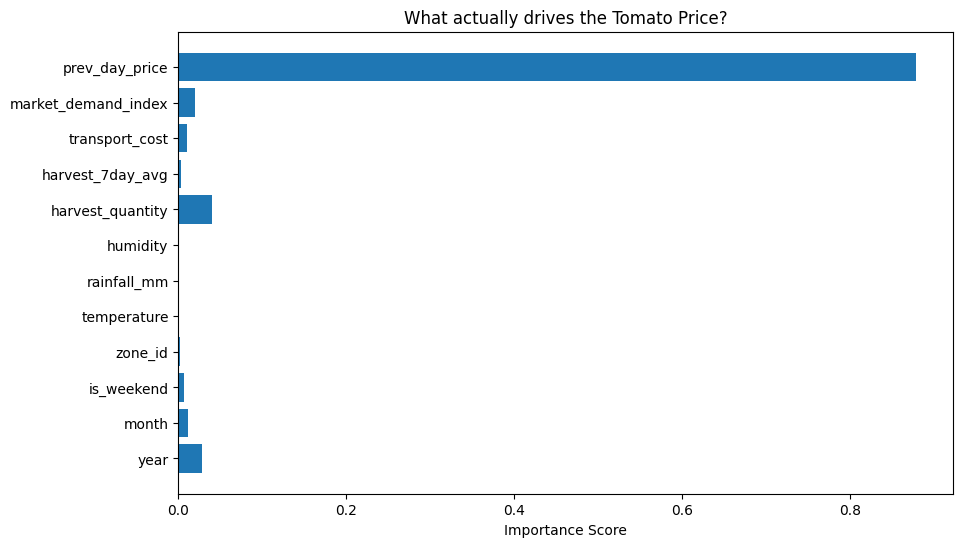

year: 0.0284
month: 0.0110
is_weekend: 0.0066
zone_id: 0.0020
temperature: 0.0003
rainfall_mm: 0.0005
humidity: 0.0003
harvest_quantity: 0.0396
harvest_7day_avg: 0.0026
transport_cost: 0.0106
market_demand_index: 0.0193
prev_day_price: 0.8787


In [18]:
import matplotlib.pyplot as plt


importance = xgb_opt.feature_importances_
feature_names = super_features


plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance)
plt.xlabel("Importance Score")
plt.title("What actually drives the Tomato Price?")
plt.show()


for name, score in zip(feature_names, importance):
    print(f"{name}: {score:.4f}")

/tmp/ipykernel_13070/1139620731.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[0], palette='viridis')


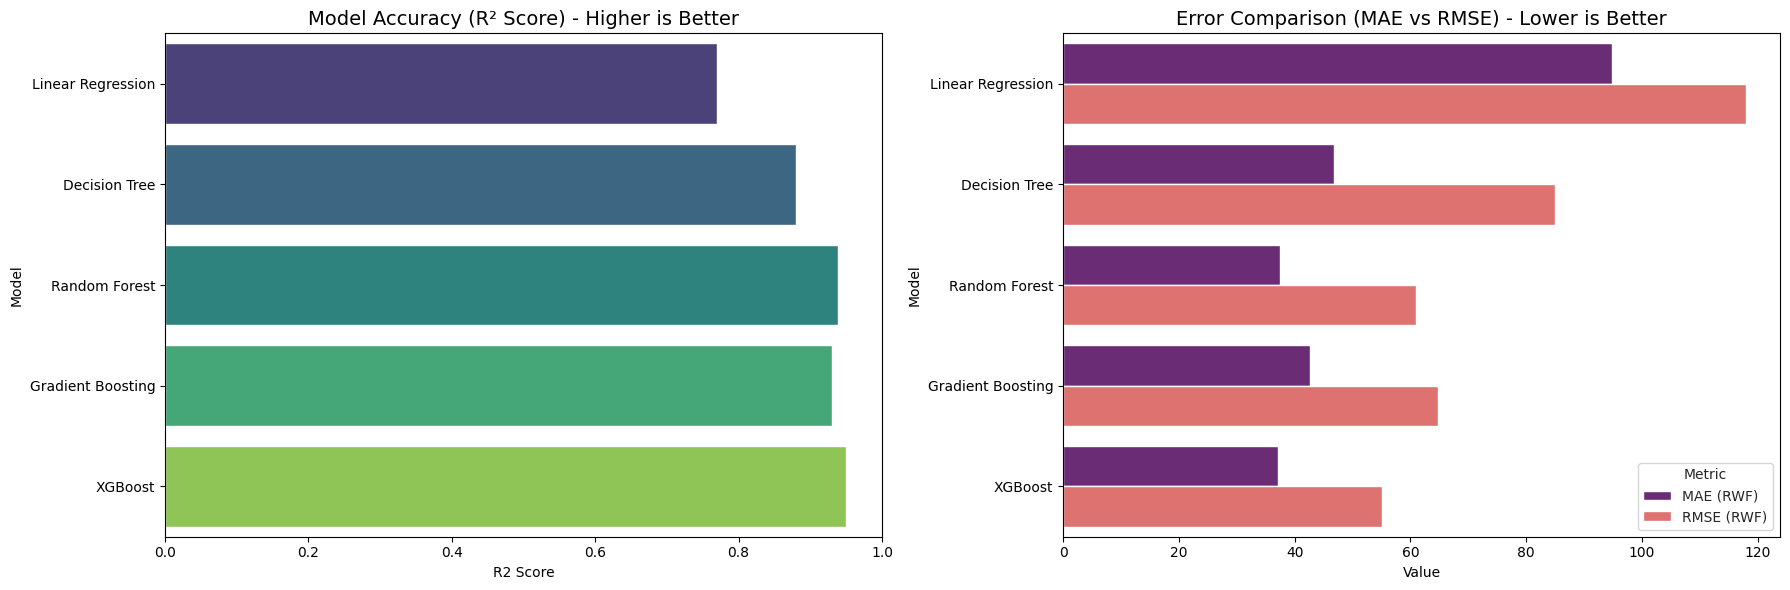

,Model,R2 Score,MAE (RWF),RMSE (RWF)
4,XGBoost,0.949679,37.081486,55.108248
2,Random Forest,0.938375,37.393620,60.984759
3,Gradient Boosting,0.930546,42.603639,64.742780
1,Decision Tree,0.880367,46.874844,84.970501
0,Linear Regression,0.769495,94.869387,117.945694


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np


models = [lr_imp, dt_imp, rf_model, gb_model, xgb_model]
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


results = []
for model, name in zip(models, model_names):
    preds = model.predict(X_test_imp)
    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, preds),
        'MAE (RWF)': mean_absolute_error(y_test, preds),
        'RMSE (RWF)': np.sqrt(mean_squared_error(y_test, preds))
    })

results_df = pd.DataFrame(results)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_style("whitegrid")


sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Accuracy (R² Score) - Higher is Better', fontsize=14)
axes[0].set_xlim(0, 1)

results_melted = results_df.melt(id_vars='Model', value_vars=['MAE (RWF)', 'RMSE (RWF)'], var_name='Metric', value_name='Value')
sns.barplot(x='Value', y='Model', hue='Metric', data=results_melted, ax=axes[1], palette='magma')
axes[1].set_title('Error Comparison (MAE vs RMSE) - Lower is Better', fontsize=14)

plt.tight_layout()
plt.savefig('model_comparison_dashboard.png')
plt.show()


display(results_df.sort_values(by='R2 Score', ascending=False))

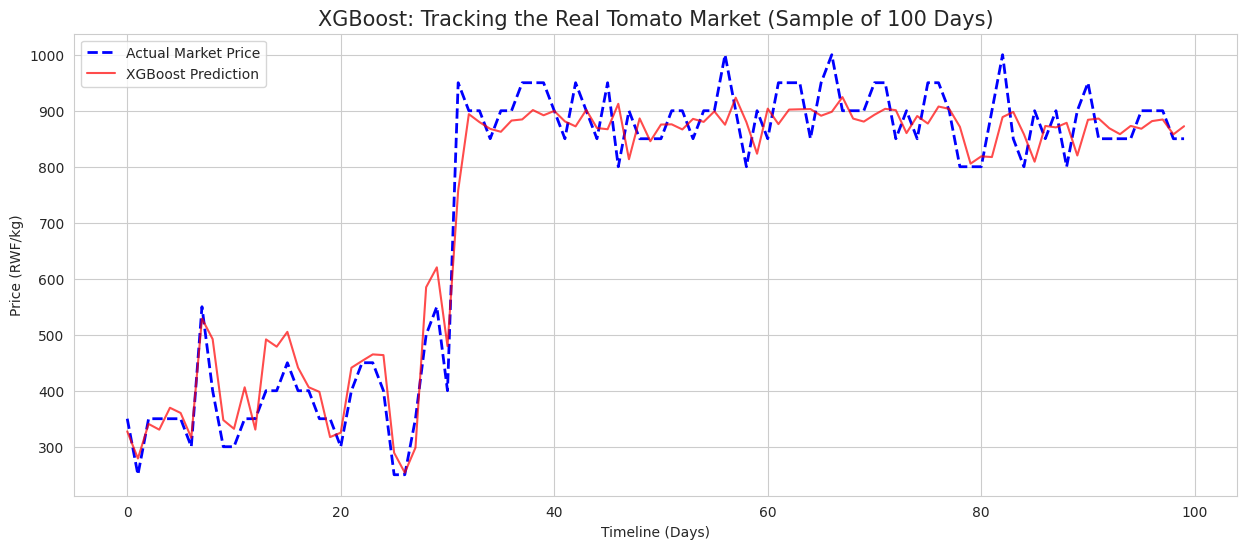

In [24]:

best_model = xgb_model
sample_size = 100

actual = y_test[:sample_size].values
predicted = best_model.predict(X_test_imp[:sample_size])

plt.figure(figsize=(15, 6))
plt.plot(actual, label='Actual Market Price', color='blue', linewidth=2, linestyle='--')
plt.plot(predicted, label='XGBoost Prediction', color='red', alpha=0.7)
plt.title('XGBoost: Tracking the Real Tomato Market (Sample of 100 Days)', fontsize=15)
plt.ylabel('Price (RWF/kg)')
plt.xlabel('Timeline (Days)')
plt.legend()
plt.savefig('prediction_accuracy_trend.png')
plt.show()

/tmp/ipykernel_13070/886021488.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='Blues_r')


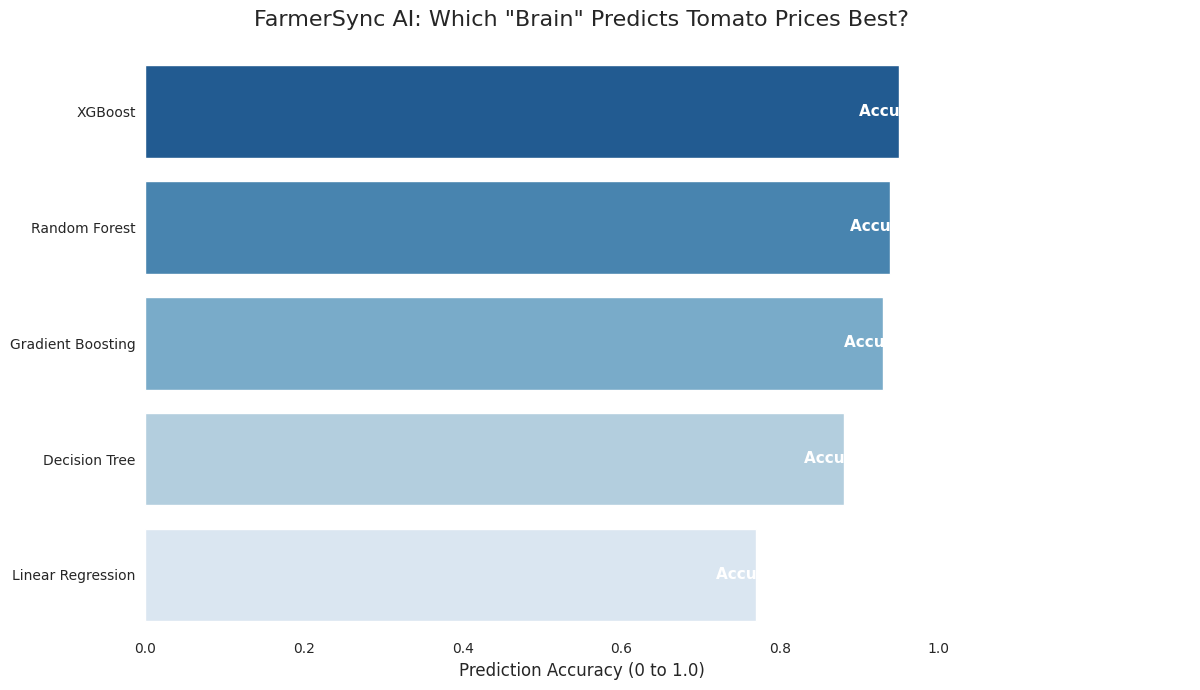

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


models = [lr_imp, dt_imp, rf_model, gb_model, xgb_model]
names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']

results = []
for model, name in zip(models, names):
    preds = model.predict(X_test_imp)
    results.append({
        'Model': name,
        'Accuracy': r2_score(y_test, preds),
        'Avg_Error': mean_absolute_error(y_test, preds)
    })


df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)


plt.figure(figsize=(12, 7))
sns.set_style("white")


ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='Blues_r')


for i, (acc, err) in enumerate(zip(df_results['Accuracy'], df_results['Avg_Error'])):
    ax.text(acc - 0.05, i, f"Accuracy: {acc:.1%} | Avg Error: {err:.1f} RWF",
            va='center', color='white', fontweight='bold', fontsize=11)


plt.title('FarmerSync AI: Which "Brain" Predicts Tomato Prices Best?', fontsize=16, pad=20)
plt.xlabel('Prediction Accuracy (0 to 1.0)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 1.1)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('final_model_leaderboard.png')
plt.show()

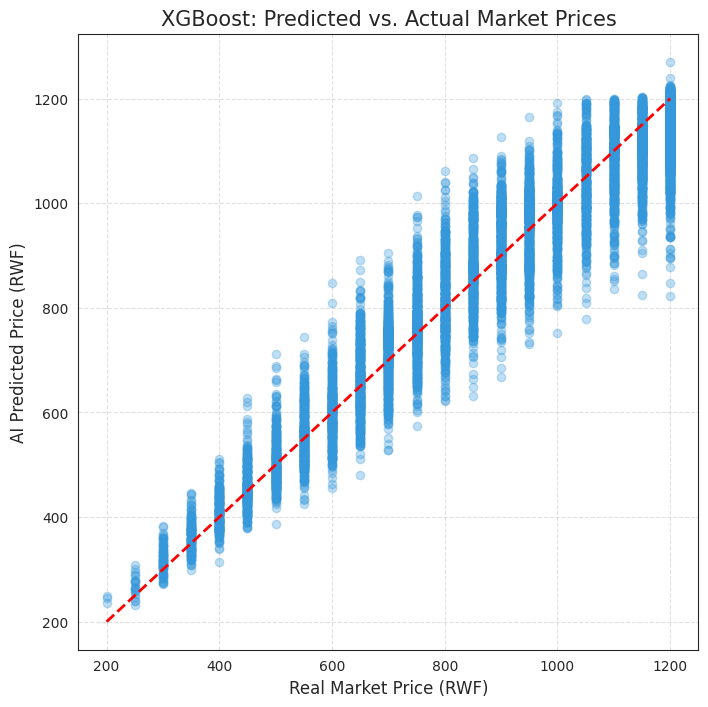

In [27]:
# Predict using the best model (XGBoost)
best_preds = xgb_model.predict(X_test_imp)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.3, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('XGBoost: Predicted vs. Actual Market Prices', fontsize=15)
plt.xlabel('Real Market Price (RWF)', fontsize=12)
plt.ylabel('AI Predicted Price (RWF)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('reality_vs_prediction.png')
plt.show()

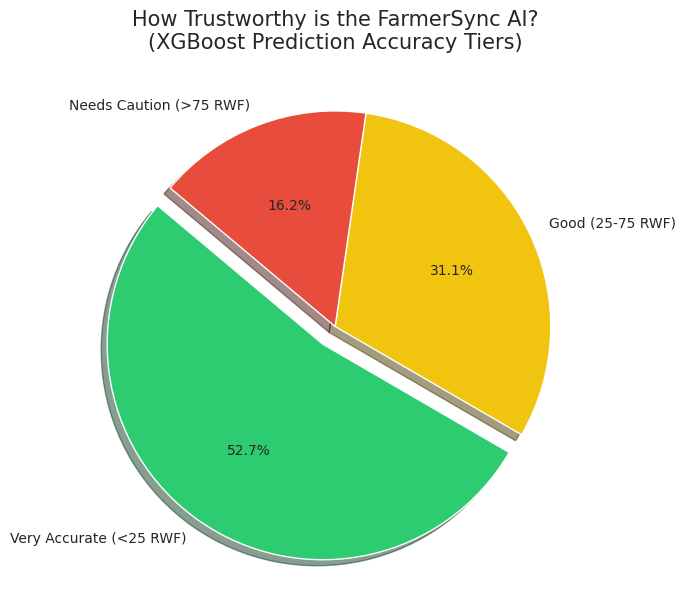

In [29]:
#  Calculate the Error for every prediction in the test set (using XGBoost)
best_preds = xgb_model.predict(X_test_imp)
errors = np.abs(y_test - best_preds)

#  Categorize the Errors
# Within 25 RWF = Very Accurate
# 25 to 75 RWF = Good
# Over 75 RWF = Low Accuracy
very_acc = len(errors[errors <= 25])
good_acc = len(errors[(errors > 25) & (errors <= 75)])
low_acc = len(errors[errors > 75])

#  Creating the Pie Chart
labels = ['Very Accurate (<25 RWF)', 'Good (25-75 RWF)', 'Needs Caution (>75 RWF)']
sizes = [very_acc, good_acc, low_acc]
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.1, 0, 0), shadow=True)
plt.title('How Trustworthy is the FarmerSync AI?\n(XGBoost Prediction Accuracy Tiers)', fontsize=15)
plt.savefig('accuracy_pie_chart.png')
plt.show()

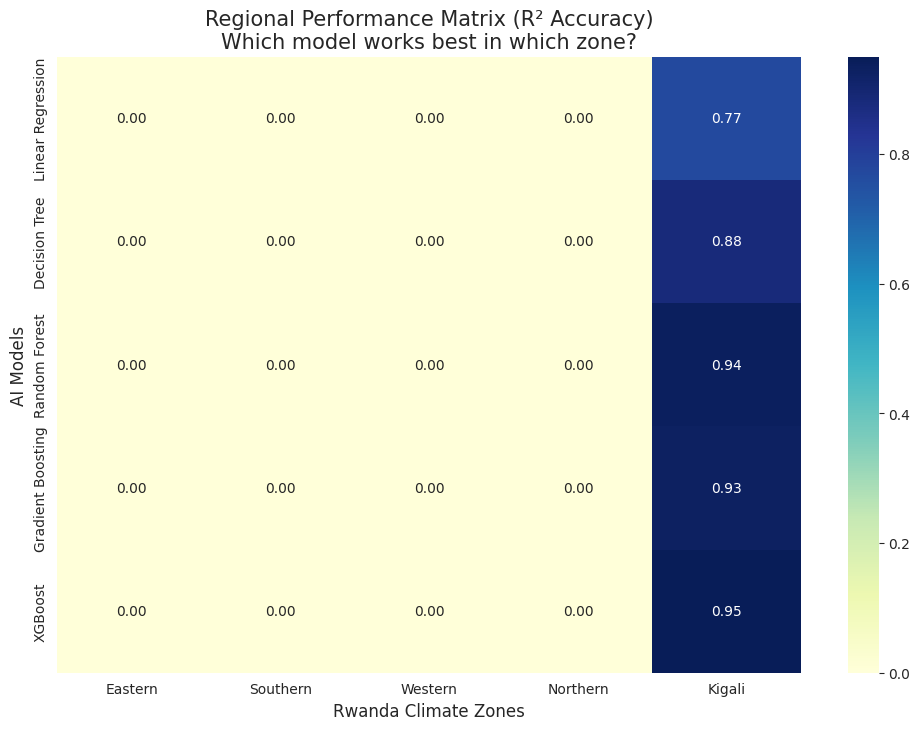

In [30]:
import seaborn as sns

#  Creating a matrix to store scores (Model vs Zone)
zones = ['Eastern', 'Southern', 'Western', 'Northern', 'Kigali']
zone_ids = [0, 1, 2, 3, 4]
matrix_data = []

for model, name in zip(models, names):
    zone_scores = []
    for z_id in zone_ids:
        # Filtering test data for this specific zone
        mask = X_test_imp['zone_id'] == z_id
        if mask.any():
            z_preds = model.predict(X_test_imp[mask])
            z_actual = y_test[mask]
            zone_scores.append(r2_score(z_actual, z_preds))
        else:
            zone_scores.append(0)
    matrix_data.append(zone_scores)

# 2. Creating the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matrix_data, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=zones, yticklabels=names)

plt.title('Regional Performance Matrix (R² Accuracy)\nWhich model works best in which zone?', fontsize=15)
plt.xlabel('Rwanda Climate Zones', fontsize=12)
plt.ylabel('AI Models', fontsize=12)
plt.savefig('zone_performance_matrix.png')
plt.show()